In [1]:
from lib import epl as EPL
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import pickle 
import time
import random #remember to do this in class
from sklearn import datasets
import matplotlib.pyplot as plt
from preprocess import preprocessing as pre
import epl.src.computeResults as compResults
from numpy.matlib import repmat
#import epl.src.multi_pattern_learning.epl_multi_pattern_learning 
#from epl.src.multi_pattern_learning.epl_multi_pattern_learning import EPLMultiPatternLearning

from sklearn.decomposition import PCA



# load the digits dataset which consists of 8X8 images of digits
digits = datasets.load_digits() #refer to when plotting









# project the 64-dimensional data to a lower dimension
pca = PCA(n_components=64, whiten=False)
pca.fit(digits.data) 

reconstructed_pca = pca.inverse_transform(pca.transform(digits.data))
#now, plot the reconstructed versions:
pre.plot_images([0, 1, 2, 3, 4, 5], reconstructed_pca, title="Digits to Learn")

images = digits.images
c_images = pca.transform(digits.data) 

#compare with c_images = digits.data

#from 2 by 2 to 1d arrays (if 2 by 2)
targets = digits.target #need to reshape images and targets
#may need to make c_images into an array

# create a map of {digt->list of images of the digits}
image_dict = {n : [] for n in range(10)}
for t, img in zip(targets, c_images):
    image_dict[t].append(img)

numPatterns = 6
#randomly choose 6 digits
digits = np.array([0, 2, 4, 5, 7, 9], ndmin = 2)


#CAN STAY IN CODE

#define utility functions
#create the training dataset by choosing the appropriate images of the digts to be learned
def get_training_data(digits, fourX=True, idx=0):
    train_data = []
    for digit in digits:
        training_image = image_dict[digit][idx]
        print(training_image)
        training_image = np.ndarray.astype(training_image, float)
        if fourX: training_image = (training_image//4)*4
        training_image = np.ndarray.flatten(training_image).tolist()
        print(training_image)
        train_data.append(training_image)
    return train_data

# generate the training data
digitss = [0, 2, 4, 5, 7, 9]
train_data = np.array(get_training_data(digits=digitss, fourX=False))

def generateTestingData(trainingData, occlusionPercent, numTestSamples,
                        sensorDynamicRange=16):  #15 to 16
    """ generate synthetic testing data for EPL network"""
    data = trainingData
    p = occlusionPercent
    n = numTestSamples
    occludedData = []
    nsensors = len(data[0])

    for i in range(0, len(data)):
        ndim = len(data[i])  # dimension of data
        for j in range(0, n):
            occludedData.append([])
            affected_ids = random.sample(range(ndim), int(p * ndim))
            for k in range(0, ndim):
                if k in affected_ids:
                    occludedData[i * n + j].append(
                        random.randint(0, sensorDynamicRange))
                else:
                    occludedData[i * n + j].append(data[i][k])
    return occludedData

scale = 15.0

trainingOdors = pre.rescaleInput(train_data, scale)

numTestSamples = 5
occlusionPercent = 0.2 # randomly perturb only 20% of the image pixels
test_data = np.array(generateTestingData(trainingData=train_data,
                                occlusionPercent=occlusionPercent,
                                numTestSamples=numTestSamples))



test_digits = repmat(digitss, numTestSamples,1).T.reshape((1,-1))
test_digitss = repmat(digits, numTestSamples,1).T.flatten()

testOdors = pre.rescaleInput(test_data, scale)
#test_data -= test_data.min()
#test_data = test_data* scale/test_data.max()
#testOdors = test_data.astype(np.int64)

## training and testing

nGamma = 5
nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
nGammaPerOdor = 5
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 



#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            net.update(sensorInput, learn_flag=learn_flag);
            pass; 
    net.reset(); 


# jaccardSimilarity(trained[-1,i], tested[-1,j])
# i is the consecutive original digit. j is the consecutive test digit
# make an array from nested loop
def jaccardSimilarity(l1=[], l2=[]):
    """ computes Jaccard similarity"""
    list1 = []
    list2 = []
    for i in range(0, len(l1)):
        list1.append((i, l1[i]))
        list2.append((i, l2[i]))
    set1 = set(list1)
    set2 = set(list2)
    intersectionSize = len(set.intersection(set1, set2))
    unionSize = len(set.union(set1, set2))
    # print intersectionSize, unionSize;
    return round(intersectionSize/float(unionSize), 4)
def computeSimilarity(l1, l2):
    """ computes similarity index """
    return jaccardSimilarity(l1, l2)
true_negative = 0
false_positive = 0



l = range(4,44,4)
#l.append(0.7)
l.append(64)
l.sort()

correctness = []
sim_times = []

l=l[0:3]
for n_components in l:
#if True:
#    n_components = l[2]
    #from lib import epl

    #Network initialization
    nMCs = n_components; 
    GCsPerNeurogenesis = 5; 
    nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
    net = EPL.EPL(nMCs, nGCs, GCsPerNeurogenesis); 
    #CHANGE THIS VARIABLE NAME (epl to net)



    #Training
    t1 = time.time(); 
    for i in range(0, len(trainingOdors)):
        print("Training odor " + str(i+1)) 
        sniff(trainingOdors[i,:n_components], learn_flag=1,nGammaPerOdor = 10); #nGammaPerOdor_training = 10 define early in code
        # changed nGammaPerOdor from 5 to 10
        net.GClayer.invokeNeurogenesis();
    #added this for loop to change structure of epl.gammaCode
    for i in range(0, len(trainingOdors)):
        sniff(trainingOdors[i,:n_components], learn_flag=0, nGammaPerOdor = nGammaPerOdor);

    #Testing
    for i in range(0, len(testOdors)):
        sniff(testOdors[i,:n_components], learn_flag=0, nGammaPerOdor = nGammaPerOdor); 
        if((i+1)%10==0 and (i+1)!=0):
            print(str(i+1) + " odors tested"); 
    t2 = time.time(); 
    print("Simulation Duration = " + str(t2-t1) + "s")
    sim_time = t2 -t1
    sim_times.append(sim_time)
    
    nGammaPerOdor_training = 10
    #Remember the first training loop uses nGammaPerOdor = 10
    #The added 5 refers to the second loop of training which uses the default variable in sniff for nGammaPerOdor
    #The added len(testOdors) * 5 refers to the third testing loop which uses the dafault variable in sniff for nGammaPerOdor
    # len(testOdors) = len(digits) * numTestSamples because generateTestOdors generates 5 noisy versions of each test digit
    # this is in order of loops
    gammaCode_size = len(trainingOdors)*(nGammaPerOdor_training + nGammaPerOdor) + digits.size* numTestSamples * nGammaPerOdor
    #digits.size=len(trainingOdors) should have numTrainingSamples
    #rename numTestSamples to numPerturbedSamples
    (gammaCode_size,len(net.gammaCode))


    trained = np.array(net.gammaCode[len(trainingOdors)*10:len(trainingOdors)*15]).reshape(nGammaPerOdor, 6, -1)
    tested = np.array(net.gammaCode[len(trainingOdors)*15:]).reshape(nGammaPerOdor, 30, -1)


    


    SImatrix = np.zeros((len(digits[0]), len(test_digits[0])), dtype =float)  
    for i in range(0, len(trained[-1])):
        for j in range(0, len(tested[-1])):
            SImatrix[i][j] = (computeSimilarity(trained[-1][i], tested[-1][j]))

         
    decisionMatrix = (SImatrix> 0.75)

    truthMatrix = np.equal(digits.T, test_digits)
    truthMatrix.shape
    #digits which is a 2d array, use reshape to 
    #operations broadcasting when comparing two arrays of different dimensions

    #this is not decisionMatrix xor truthMatrix
    #returns all the places where the decision is correct (trues are trues and falses re false)
    #take a look at this logic
    # Try this alternative expression: correct = not (decisionMatrix xor truthMatrix)
    correct = ~(decisionMatrix ^ truthMatrix)

    correctID = np.count_nonzero(correct)
    per_correct = float(correctID)/SImatrix.size *100

    correctness.append(per_correct)

<Figure size 800x800 with 6 Axes>

[-1.25946645e+00  2.12748835e+01 -9.46305462e+00  1.30141887e+01
 -7.12882278e+00 -7.44065876e+00  3.25283716e+00  2.55347036e+00
 -5.81842142e-01  3.62569695e+00  2.58595688e+00  1.55160708e+00
  8.54496709e-01 -3.33874935e+00  5.90658968e+00  2.74359339e+00
  4.19836907e-01 -8.98149693e-01  7.02610866e-01 -3.46211868e+00
  2.68084958e+00  1.00944951e+00  2.00970276e+00  1.29531479e+00
  1.17887873e+00  2.30058185e+00  3.67072108e+00 -9.43668900e-01
 -1.13250195e+00  2.35979550e+00 -1.81738593e+00 -7.55016284e-01
  1.62841809e-01 -2.11297739e+00  1.09482318e+00  1.95685532e-01
 -8.99936129e-02 -2.76374068e+00  1.08888322e+00  2.06004009e-01
  1.70451133e+00  5.81318379e-01  7.12698392e-01 -1.88038868e-01
  6.28313404e-01 -5.94986903e-01  4.76923307e-02 -7.13294070e-01
 -3.39315207e-01  4.30994090e-02 -4.21401144e-01 -1.21887592e-01
 -6.33281370e-02 -5.70236060e-02 -4.87854310e-02 -1.81625690e-03
  1.11015905e-02 -1.54744844e-03  8.24746988e-03  2.14808613e-03
  1.04388936e-03  1.08468

Training odor 4
Training odor 5
Training odor 6
10 odors tested
20 odors tested
30 odors tested
Simulation Duration = 4.38100004196s
Training odor 1
Training odor 2
Training odor 3
Training odor 4
Training odor 5
Training odor 6
10 odors tested
20 odors tested
30 odors tested
Simulation Duration = 9.22699999809s
Training odor 1
Training odor 2
Training odor 3
Training odor 4
Training odor 5
Training odor 6
10 odors tested
20 odors tested
30 odors tested
Simulation Duration = 15.4979999065s


In [2]:
correctness

[83.33333333333334, 83.33333333333334, 83.33333333333334]

In [3]:
truthMatrix

array([[ True,  True,  True,  True,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False,  True,  True,  True,  True,
         True, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False,  True,  True,  True,  True,  True, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False,  True,  True,  True,
         True,  True, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False,

In [4]:
sim_times

[4.38100004196167, 9.226999998092651, 15.497999906539917]

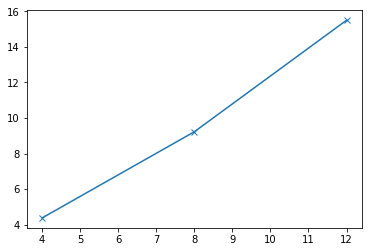

In [5]:
plt.plot(l, sim_times, "x-")
plt.show()

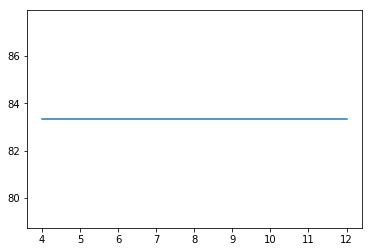

In [6]:
plt.plot(l, correctness)

In [7]:
l

[4, 8, 12]

In [8]:
train_data.shape

(6L, 64L)

In [9]:
test_data.shape

(30L, 64L)

In [10]:
trainingOdors.shape

(6L, 64L)

In [11]:
testOdors.shape

(30L, 64L)

In [12]:
trainingOdors[0,:n_components]

array([ 6, 14,  3, 11,  4,  4,  8,  7,  6,  8,  7,  7], dtype=int64)